# 1. Setup and Data Downloading

In [1]:
import os, time, json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

os.environ.setdefault("KERAS_BACKEND", "tensorflow")   # proposal uses TensorFlow/Keras
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"                # hides harmless "Corrupt JPEG data" spam
from keras import applications as ap
from keras.callbacks import EarlyStopping
from keras.layers import Dense, Dropout, GlobalAveragePooling2D
from keras.models import Sequential
from keras.optimizers import Adam
from keras.src.legacy.preprocessing.image import ImageDataGenerator
from keras.applications.resnet50 import preprocess_input

# If tensorflow is missing in this environment, run this once:
# %pip install tensorflow

In [2]:
# Look for the dataset in a few likely places (first one that exists is used).
candidates = [
    Path(os.environ["PET_DIR"]) if "PET_DIR" in os.environ else None,
    Path.cwd() / "data" / "kaggle-cats-and-dogs" / "PetImages",
    Path.cwd().parent / "data" / "kaggle-cats-and-dogs" / "PetImages",
    Path.cwd() / "PetImages",
    Path.home() / "Downloads" / "kagglecatsanddogs_3367a" / "PetImages",
]
candidates = [p for p in candidates if p is not None]
local_dir = next((p for p in candidates if p.exists()), None)
if local_dir is None:
    raise FileNotFoundError("Dataset folder not found. Checked:\n" + "\n".join(map(str, candidates)))

directory = os.path.abspath(str(local_dir))
print(f"Using dataset directory: {directory}")
print("Folder names:", sorted(p.name for p in local_dir.iterdir() if p.is_dir()))

Using dataset directory: /Users/sabyasachi/Documents/programming_forai_project_Proposal/kagglecatsanddogs_3367a/PetImages
Folder names: ['Cat', 'Dog']


In [3]:
os.listdir(directory)

['Cat', 'Dog']

# 2. Loading and Processing Data

In [4]:
images = []
labels = []

try:
    for foldr in sorted(os.listdir(directory)):
        class_dir = os.path.join(directory, foldr)
        if not os.path.isdir(class_dir):
            continue
        for filee in sorted(os.listdir(class_dir)):
            if filee.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(os.path.join(foldr, filee))
                labels.append(foldr)
except Exception as e:
    print(f'Error: {e}')

In [5]:
data = pd.DataFrame({
    'Images': images,
    'Labels': labels
})

# Clean the dataset before plotting or training.
data = data.dropna(subset=['Images', 'Labels']).copy()
data = data[data['Images'].str.lower().str.endswith(('.jpg', '.jpeg', '.png'))].copy()
data = data.drop_duplicates(subset=['Images']).reset_index(drop=True)

print('Total rows after cleaning:', len(data))
print('Duplicate rows:', data.duplicated(subset=['Images']).sum())
print('Missing values:\n', data.isna().sum())
print('Label distribution:\n', data['Labels'].value_counts())
print(data.head())


Total rows after cleaning: 24959
Duplicate rows: 0
Missing values:
 Images    0
Labels    0
dtype: int64
Label distribution:
 Labels
Cat    12490
Dog    12469
Name: count, dtype: int64
         Images Labels
0     Cat/0.jpg    Cat
1     Cat/1.jpg    Cat
2    Cat/10.jpg    Cat
3   Cat/100.jpg    Cat
4  Cat/1000.jpg    Cat


In [6]:
from PIL import Image
bad_files = []
for img_path in data['Images']:
    try:
        with Image.open(os.path.join(directory, img_path)) as im:
            im.load()                    # fully decode the pixels (verify() alone misses truncated files)
            im.convert('RGB')            # same conversion the generator performs (handles 2-channel / palette / gray files)
            if min(im.size) < 10:
                raise ValueError('degenerate image')
    except Exception:
        bad_files.append(img_path)
data = data[~data['Images'].isin(bad_files)].reset_index(drop=True)
print(f'Removed {len(bad_files)} corrupt files')
print('Remaining:', len(data))

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Removed 1 corrupt files
Remaining: 24958


In [7]:
print('Dataset sample:')
print(data.head())
print('\nDataset tail:')
print(data.tail())
print(f'\nTotal images: {len(data)}')
print('\nClass distribution:')
print(data['Labels'].value_counts())

Dataset sample:
         Images Labels
0     Cat/0.jpg    Cat
1     Cat/1.jpg    Cat
2    Cat/10.jpg    Cat
3   Cat/100.jpg    Cat
4  Cat/1000.jpg    Cat

Dataset tail:
             Images Labels
24953  Dog/9995.jpg    Dog
24954  Dog/9996.jpg    Dog
24955  Dog/9997.jpg    Dog
24956  Dog/9998.jpg    Dog
24957  Dog/9999.jpg    Dog

Total images: 24958

Class distribution:
Labels
Cat    12489
Dog    12469
Name: count, dtype: int64


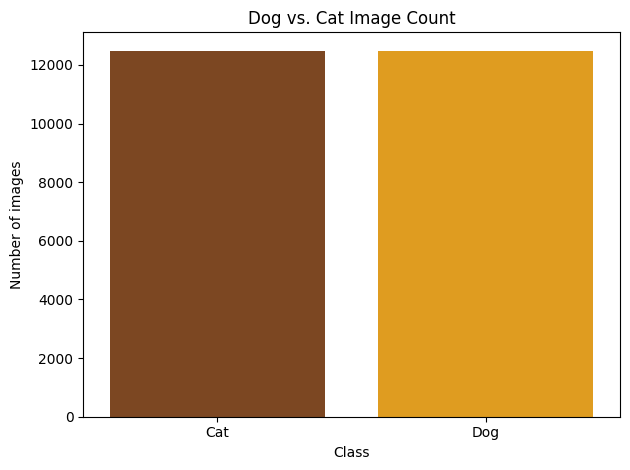

In [8]:
colors = ['#8B4513', 'orange']

sns.countplot(data=data, x='Labels', hue='Labels', palette=colors, dodge=False, legend=False)
plt.title('Dog vs. Cat Image Count')
plt.xlabel('Class')
plt.ylabel('Number of images')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


# 3. Visualizing the Data
plotting one sample image from each category using OpenCV

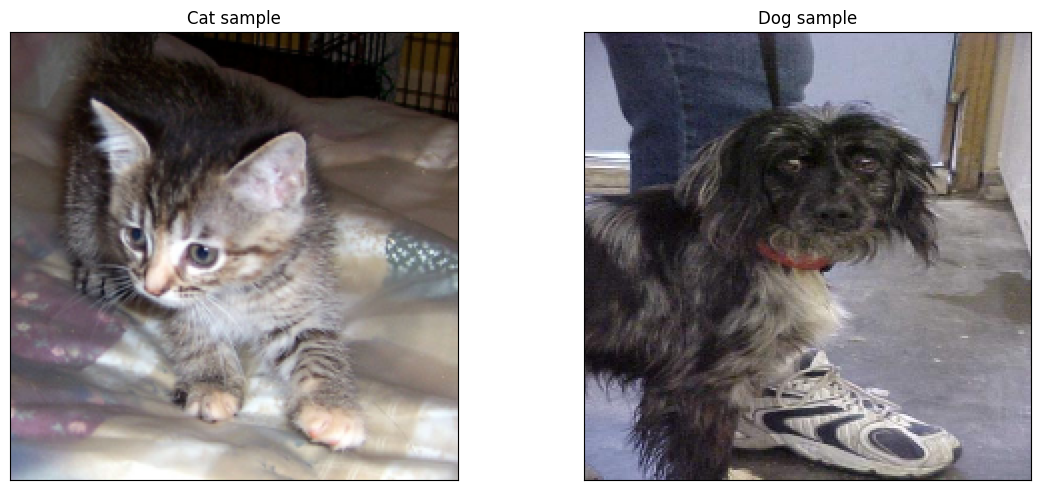

In [9]:
plt.figure(figsize=(12, 5))
classes = sorted(data['Labels'].unique())

for i, label in enumerate(classes):
    sample = data[data['Labels'] == label].sample(1).iloc[0]
    img_path = os.path.join(directory, sample['Images'])
    img = cv2.imread(img_path)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (224, 224))

    plt.subplot(1, len(classes), i + 1)
    plt.imshow(img)
    plt.title(f'{label.capitalize()} sample', fontsize=12)
    plt.xticks([])
    plt.yticks([])

plt.tight_layout()
plt.show()


# 4. Data Splitting

In [10]:
# Rebuild the DataFrame if it was cleared by a previous rerun.
if 'data' not in globals() or data.empty:   # FIX: old check ('Images' not in locals()) was always True and re-added the corrupt files
    images = []
    labels = []
    for foldr in sorted(os.listdir(directory)):
        class_dir = os.path.join(directory, foldr)
        if not os.path.isdir(class_dir):
            continue
        for filee in sorted(os.listdir(class_dir)):
            if filee.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(os.path.join(foldr, filee))
                labels.append(foldr)
    data = pd.DataFrame({'Images': images, 'Labels': labels})
    data = data.dropna(subset=['Images', 'Labels']).copy()
    data = data[data['Images'].str.lower().str.endswith(('.jpg', '.jpeg', '.png'))].copy()
    data = data.drop_duplicates(subset=['Images']).reset_index(drop=True)

# Keep labels as strings for Keras ImageDataGenerator with binary class_mode.
data = data[data['Labels'].astype(str).str.strip().str.title().isin(['Cat', 'Dog'])].copy()
data['Labels'] = data['Labels'].astype(str).str.strip().str.title()

if len(data) == 0:
    raise ValueError('Dataset is empty. Check the dataset folder and run the loading cells again.')

if data['Labels'].isna().any():
    raise ValueError(f"Unexpected label values found: {data[data['Labels'].isna()]['Labels'].unique()}")

# 80% train / 10% validation / 10% test, stratified (matches the proposal)
train_df, temp_df = train_test_split(data, test_size=0.2, random_state=42, stratify=data['Labels'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['Labels'])

optimizer = Adam(learning_rate=0.0001)

print(f'Train: {len(train_df)} | Validation: {len(val_df)} | Test: {len(test_df)}')
print('Label counts:')
print(data['Labels'].value_counts())


Train: 19966 | Validation: 2496 | Test: 2496
Label counts:
Labels
Cat    12489
Dog    12469
Name: count, dtype: int64


# 5. Data Augmentation

In [11]:
# Ensure the split DataFrame is valid before creating image batches.
if 'train_df' not in globals() or 'test_df' not in globals():
    raise ValueError('Run the data split cell before this augmentation cell.')

train_df = train_df.copy()
val_df = val_df.copy()
test_df = test_df.copy()

# Normalize labels so Keras sees strings, not numeric 0/1 left over from a rerun.
train_df['Labels'] = train_df['Labels'].astype(str).str.strip().str.title()
val_df['Labels'] = val_df['Labels'].astype(str).str.strip().str.title()
test_df['Labels'] = test_df['Labels'].astype(str).str.strip().str.title()

# If a stale run left 0/1 values, convert them back to Cat/Dog names.
train_df['Labels'] = train_df['Labels'].replace({'0': 'Cat', '1': 'Dog'})
val_df['Labels'] = val_df['Labels'].replace({'0': 'Cat', '1': 'Dog'})
test_df['Labels'] = test_df['Labels'].replace({'0': 'Cat', '1': 'Dog'})

trainimgen = ImageDataGenerator(
    preprocessing_function=preprocess_input,   # FIX: was missing, so train images were scaled differently from val/test
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    shear_range=0.2,
)

train_data = trainimgen.flow_from_dataframe(
    dataframe=train_df,
    directory=directory,
    x_col='Images',
    y_col='Labels',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='binary',
    batch_size=16,
)


Found 19966 validated image filenames belonging to 2 classes.


In [12]:
testimgen = ImageDataGenerator(preprocessing_function=preprocess_input)

val_data = testimgen.flow_from_dataframe(
    dataframe=val_df,
    directory=directory,
    x_col='Images',
    y_col='Labels',
    target_size=(224,224),
    color_mode='rgb',
    class_mode='binary',
    batch_size=16,
    shuffle=False
)


test_data = testimgen.flow_from_dataframe(
    dataframe=test_df,
    directory=directory,
    x_col='Images',
    y_col='Labels',
    target_size=(224,224),
    color_mode='rgb',
    class_mode='binary',
    batch_size=16,
    shuffle=False # For test data, it's crucial to set shuffle=False. This ensures the prediction order matches the label order, which is necessary for correct evaluation with metrics like a confusion matrix.
)

Found 2496 validated image filenames belonging to 2 classes.
Found 2496 validated image filenames belonging to 2 classes.


# 6. Building the Tranfer Learning (ResNet50) Model

In [13]:
processing = ap.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

processing.trainable = False

Model = Sequential(
    [
        processing,
        GlobalAveragePooling2D(),
        Dense(256, activation='relu'),
        Dropout(0.2),
        Dense(128, activation='relu'),
        Dense(1, activation='sigmoid')
    ]
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step


In [14]:
Model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,145,281 (92.11 MB)

 Trainable params: 557,569 (2.13 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [15]:
callbacky = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
Model.compile(optimizer=Adam(learning_rate=0.0001), loss='binary_crossentropy', metrics=['accuracy'])

# 7. Model  Training

In [16]:
t0 = time.time()
history = Model.fit(
    train_data,
    epochs=5,
    validation_data=val_data,      # FIX: was test_data, which leaked the test set into early stopping
    callbacks=[callbacky]
)
resnet_train_secs = time.time() - t0
print(f'ResNet50 training time: {resnet_train_secs/60:.1f} min')

Epoch 1/5
 990/1248 ━━━━━━━━━━━━━━━━━━━━ 4:25 1s/step - accuracy: 0.9742 - loss: 0.0703

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1453s 1s/step - accuracy: 0.9758 - loss: 0.0668 - val_accuracy: 0.9904 - val_loss: 0.0288
Epoch 2/5
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1568s 1s/step - accuracy: 0.9841 - loss: 0.0417 - val_accuracy: 0.9920 - val_loss: 0.0253
Epoch 3/5
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1222s 979ms/step - accuracy: 0.9868 - loss: 0.0378 - val_accuracy: 0.9896 - val_loss: 0.0243
Epoch 4/5
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 906s 726ms/step - accuracy: 0.9872 - loss: 0.0322 - val_accuracy: 0.9900 - val_loss: 0.0286
Epoch 5/5
1248/1248 ━━━━━━━━━━━━━━━━━━━━ 1483s 1s/step - accuracy: 0.9890 - loss: 0.0287 - val_accuracy: 0.9884 - val_loss: 0.0255
ResNet50 training time: 110.5 min


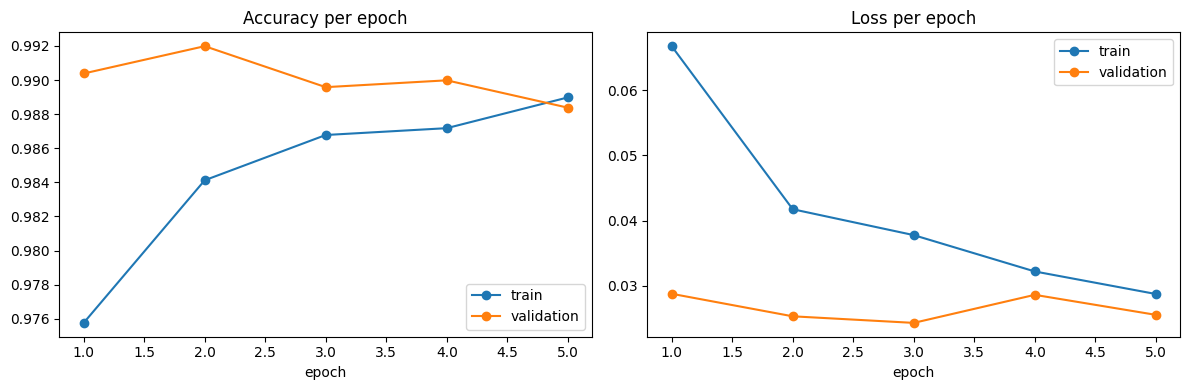

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ep = range(1, len(history.history['loss']) + 1)
ax[0].plot(ep, history.history['accuracy'], marker='o', label='train')
ax[0].plot(ep, history.history['val_accuracy'], marker='o', label='validation')
ax[0].set(title='Accuracy per epoch', xlabel='epoch'); ax[0].legend()
ax[1].plot(ep, history.history['loss'], marker='o', label='train')
ax[1].plot(ep, history.history['val_loss'], marker='o', label='validation')
ax[1].set(title='Loss per epoch', xlabel='epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

# 8. Evaluating Model performance

In [18]:
# Final result on the held-out TEST set (never used for training or early stopping)
Model.evaluate(test_data)

156/156 ━━━━━━━━━━━━━━━━━━━━ 153s 978ms/step - accuracy: 0.9924 - loss: 0.0187


[0.018707068637013435, 0.9923878312110901]

In [19]:
# Plotting a Confusion Matrix
preds = Model.predict(test_data)

# Converting probabilities to binary classes (0 or 1)
# The threshold 0.5 is standard for binary classification with a sigmoid activation
preds_classes = (preds > 0.5).astype(int).flatten()

156/156 ━━━━━━━━━━━━━━━━━━━━ 153s 970ms/step


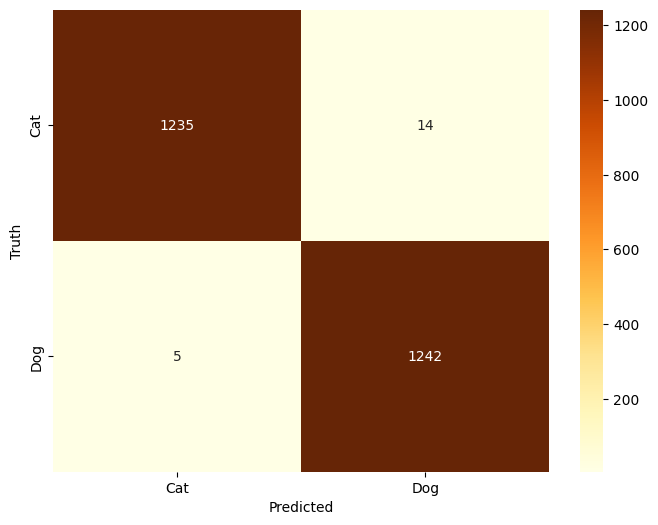

In [20]:
true_labels = test_data.classes

cm = confusion_matrix(true_labels, preds_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr', 
            xticklabels=list(test_data.class_indices.keys()), 
            yticklabels=list(test_data.class_indices.keys()))
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.show()

In [21]:
from sklearn.metrics import classification_report
print(classification_report(true_labels, preds_classes, target_names=list(test_data.class_indices.keys())))

              precision    recall  f1-score   support

         Cat       1.00      0.99      0.99      1249
         Dog       0.99      1.00      0.99      1247

    accuracy                           0.99      2496
   macro avg       0.99      0.99      0.99      2496
weighted avg       0.99      0.99      0.99      2496



In [26]:
os.makedirs("models", exist_ok=True)
Model.save("models/resnet50-frozen.keras")

# 9. Custom CNN from scratch (depth, batch norm, dropout ablation)
This part is promised in the proposal. It uses a `tf.data` pipeline built from the same `train_df` / `val_df` / `test_df` split, so every model sees exactly the same images.

In [32]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_curve, roc_auc_score, classification_report)

AUTOTUNE = tf.data.AUTOTUNE
SEED, BATCH, IMG_CNN = 42, 32, 128
EPOCHS_CNN, EPOCHS_OPT = 5, 5
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/metrics", exist_ok=True)
os.makedirs("results/training", exist_ok=True)
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight"})
keras.utils.set_random_seed(SEED)

def to_ds(frame, size, training):
    frame = frame.copy()
    valid = []
    for path, label in zip(frame["Images"], frame["Labels"]):
        full_path = os.path.join(directory, path)
        try:
            with Image.open(full_path) as im:
                rgb = im.convert("RGB")
                rgb.load()
                if min(rgb.size) < 10:
                    raise ValueError("degenerate image")
            valid.append((path, label))
        except Exception:
            continue
    if not valid:
        raise ValueError("No valid RGB images remain in this split. Check the dataset and Clean step.")

    paths = [p for p, _ in valid]
    labels = [lab for _, lab in valid]
    y = (np.asarray(labels, dtype=str) == "Dog").astype("float32")

    def load(path, lab):
        def decode_rgb(path_tensor):
            image_path = path_tensor.numpy().decode("utf-8")
            with Image.open(image_path) as im:
                return np.asarray(im.convert("RGB"), dtype=np.uint8)

        img = tf.py_function(decode_rgb, [path], Tout=tf.uint8)
        img.set_shape([None, None, 3])
        img = tf.image.resize(img, (size, size))
        return tf.cast(img, tf.float32), lab

    ds = tf.data.Dataset.from_tensor_slices((
        tf.constant([os.path.join(directory, p) for p in paths]),
        tf.constant(y, dtype=tf.float32),
    ))
    ds = ds.map(load, num_parallel_calls=AUTOTUNE).cache()
    if training:
        ds = ds.shuffle(2048, seed=SEED, reshuffle_each_iteration=True)
    return ds.batch(BATCH).prefetch(AUTOTUNE), y

cnn_train, _ = to_ds(train_df, IMG_CNN, True)
cnn_val, y_val = to_ds(val_df, IMG_CNN, False)
cnn_test, y_test = to_ds(test_df, IMG_CNN, False)
assert (y_test == test_data.classes).all(), "test order mismatch between generator and tf.data"

def make_augment():
    return keras.Sequential([layers.RandomFlip("horizontal"), layers.RandomRotation(0.06),
                             layers.RandomZoom(0.15), layers.RandomContrast(0.1)], name="augment")

def build_cnn(filters=(32, 64, 128), use_bn=True, dropout=0.3, name="cnn"):
    inp = keras.Input((IMG_CNN, IMG_CNN, 3))
    x = make_augment()(inp)
    x = layers.Rescaling(1 / 255.0)(x)
    for f in filters:
        x = layers.Conv2D(f, 3, padding="same", use_bias=not use_bn)(x)
        if use_bn: x = layers.BatchNormalization()(x)
        x = layers.Activation("relu")(x)
        x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    x = layers.Dense(128, activation="relu")(x)
    if dropout > 0: x = layers.Dropout(dropout)(x)
    return keras.Model(inp, layers.Dense(1, activation="sigmoid")(x), name=name)

def get_optimizer(kind, lr):
    return {"adam": lambda: keras.optimizers.Adam(lr), "rmsprop": lambda: keras.optimizers.RMSprop(lr),
            "sgd": lambda: keras.optimizers.SGD(lr, momentum=0.9)}[kind]()

def train(model, epochs, opt="adam", lr=1e-3):
    model.compile(get_optimizer(opt, lr), loss="binary_crossentropy", metrics=["accuracy"])
    cbs = [keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
           keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6)]
    t0 = time.time()
    h = model.fit(cnn_train, validation_data=cnn_val, epochs=epochs, callbacks=cbs, verbose=2)
    return h.history, time.time() - t0

RESULTS, PROBS, HIST, VAL_ACC = {}, {}, {}, {}
def score(name, p, y, secs, params):
    pred = (p > 0.5).astype(int); PROBS[name] = p
    RESULTS[name] = dict(test_acc=accuracy_score(y, pred), precision=precision_score(y, pred), recall=recall_score(y, pred),
                         f1=f1_score(y, pred), auc=roc_auc_score(y, p), train_min=secs / 60, params=params)

CNN_CONFIGS = {
    "CNN-A  3 blocks, no BN, no dropout": dict(filters=(32, 64, 128), use_bn=False, dropout=0.0),
    "CNN-B  3 blocks, BN":                dict(filters=(32, 64, 128), use_bn=True,  dropout=0.0),
    "CNN-C  3 blocks, BN, dropout 0.3":   dict(filters=(32, 64, 128), use_bn=True,  dropout=0.3),
    "CNN-D  4 blocks, BN, dropout 0.5":   dict(filters=(32, 64, 128, 256), use_bn=True, dropout=0.5),
}
CNN_MODELS = {}
for name, cfg in CNN_CONFIGS.items():
    print("\n=====", name)
    keras.utils.set_random_seed(SEED)
    m = build_cnn(**cfg, name=name.split()[0].replace("-", "_").lower())
    HIST[name], secs = train(m, EPOCHS_CNN)
    CNN_MODELS[name] = m
    VAL_ACC[name] = accuracy_score(y_val, (m.predict(cnn_val, verbose=0).ravel() > 0.5).astype(int))
    score(name, m.predict(cnn_test, verbose=0).ravel(), y_test, secs, m.count_params())

BEST_CNN = max(VAL_ACC, key=VAL_ACC.get)
print("\nBest custom CNN on validation:", BEST_CNN, f"({VAL_ACC[BEST_CNN]:.4f})")


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))



===== CNN-A  3 blocks, no BN, no dropout
Epoch 1/5
624/624 - 187s - 300ms/step - accuracy: 0.5749 - loss: 0.6686 - val_accuracy: 0.6366 - val_loss: 0.6406 - learning_rate: 0.0010
Epoch 2/5
624/624 - 135s - 217ms/step - accuracy: 0.6507 - loss: 0.6232 - val_accuracy: 0.6875 - val_loss: 0.5965 - learning_rate: 0.0010
Epoch 3/5
624/624 - 129s - 206ms/step - accuracy: 0.6866 - loss: 0.5851 - val_accuracy: 0.6927 - val_loss: 0.5932 - learning_rate: 0.0010
Epoch 4/5
624/624 - 135s - 216ms/step - accuracy: 0.7150 - loss: 0.5562 - val_accuracy: 0.6751 - val_loss: 0.5845 - learning_rate: 0.0010
Epoch 5/5
624/624 - 139s - 222ms/step - accuracy: 0.7310 - loss: 0.5330 - val_accuracy: 0.7452 - val_loss: 0.5371 - learning_rate: 0.0010

===== CNN-B  3 blocks, BN
Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


624/624 - 232s - 372ms/step - accuracy: 0.6401 - loss: 0.6278 - val_accuracy: 0.5913 - val_loss: 0.6731 - learning_rate: 0.0010
Epoch 2/5
624/624 - 229s - 366ms/step - accuracy: 0.6938 - loss: 0.5734 - val_accuracy: 0.6518 - val_loss: 0.6473 - learning_rate: 0.0010
Epoch 3/5
624/624 - 230s - 368ms/step - accuracy: 0.7133 - loss: 0.5517 - val_accuracy: 0.6807 - val_loss: 0.6472 - learning_rate: 0.0010
Epoch 4/5
624/624 - 231s - 370ms/step - accuracy: 0.7324 - loss: 0.5302 - val_accuracy: 0.7107 - val_loss: 0.5527 - learning_rate: 0.0010
Epoch 5/5
624/624 - 234s - 376ms/step - accuracy: 0.7377 - loss: 0.5187 - val_accuracy: 0.5741 - val_loss: 1.1538 - learning_rate: 0.0010

===== CNN-C  3 blocks, BN, dropout 0.3
Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


624/624 - 239s - 383ms/step - accuracy: 0.6032 - loss: 0.6586 - val_accuracy: 0.5204 - val_loss: 0.8792 - learning_rate: 0.0010
Epoch 2/5
624/624 - 240s - 384ms/step - accuracy: 0.6502 - loss: 0.6185 - val_accuracy: 0.5204 - val_loss: 0.8516 - learning_rate: 0.0010
Epoch 3/5
624/624 - 236s - 378ms/step - accuracy: 0.6834 - loss: 0.5897 - val_accuracy: 0.6474 - val_loss: 0.6150 - learning_rate: 0.0010
Epoch 4/5
624/624 - 239s - 383ms/step - accuracy: 0.7031 - loss: 0.5692 - val_accuracy: 0.7019 - val_loss: 0.5619 - learning_rate: 0.0010
Epoch 5/5
624/624 - 235s - 377ms/step - accuracy: 0.7133 - loss: 0.5563 - val_accuracy: 0.7276 - val_loss: 0.5415 - learning_rate: 0.0010

===== CNN-D  4 blocks, BN, dropout 0.5
Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


624/624 - 288s - 462ms/step - accuracy: 0.5989 - loss: 0.6733 - val_accuracy: 0.6486 - val_loss: 0.6418 - learning_rate: 0.0010
Epoch 2/5
624/624 - 285s - 456ms/step - accuracy: 0.6634 - loss: 0.6144 - val_accuracy: 0.7179 - val_loss: 0.5673 - learning_rate: 0.0010
Epoch 3/5
624/624 - 292s - 468ms/step - accuracy: 0.7022 - loss: 0.5767 - val_accuracy: 0.6999 - val_loss: 0.5755 - learning_rate: 0.0010
Epoch 4/5
624/624 - 291s - 466ms/step - accuracy: 0.7205 - loss: 0.5493 - val_accuracy: 0.7107 - val_loss: 0.5658 - learning_rate: 0.0010
Epoch 5/5
624/624 - 285s - 457ms/step - accuracy: 0.7378 - loss: 0.5297 - val_accuracy: 0.6190 - val_loss: 0.6939 - learning_rate: 0.0010

Best custom CNN on validation: CNN-A  3 blocks, no BN, no dropout (0.7452)


# 10. Optimizer and learning-rate comparison (on the best CNN configuration)

In [33]:
if "BEST_CNN" not in globals():
    if "VAL_ACC" in globals() and VAL_ACC:
        BEST_CNN = max(VAL_ACC, key=VAL_ACC.get)
    else:
        BEST_CNN = "CNN-B  3 blocks, BN"

# Rebuild datasets with the current RGB-safe loader; this replaces any stale
# datasets left in the notebook kernel from an earlier version of section 9.
cnn_train, _ = to_ds(train_df, IMG_CNN, True)
cnn_val, y_val = to_ds(val_df, IMG_CNN, False)
cnn_test, y_test = to_ds(test_df, IMG_CNN, False)
assert (y_test == test_data.classes).all(), "test order mismatch between generator and tf.data"

OPT_CONFIGS = {"Adam 1e-3": ("adam", 1e-3), "Adam 1e-4": ("adam", 1e-4),
               "RMSprop 1e-3": ("rmsprop", 1e-3), "SGD+momentum 1e-2": ("sgd", 1e-2)}
OPT_HIST, rows = {}, []
for oname, (kind, lr) in OPT_CONFIGS.items():
    print("\n=====", oname)
    keras.utils.set_random_seed(SEED)
    m = build_cnn(**CNN_CONFIGS[BEST_CNN], name="opt_test")
    OPT_HIST[oname], secs = train(m, EPOCHS_OPT, opt=kind, lr=lr)
    va = accuracy_score(y_val, (m.predict(cnn_val, verbose=0).ravel() > 0.5).astype(int))
    rows.append(dict(optimizer=oname, val_acc=va, best_val_loss=min(OPT_HIST[oname]["val_loss"]),
                     epochs_run=len(OPT_HIST[oname]["loss"]), train_min=secs / 60))
opt_table = pd.DataFrame(rows).set_index("optimizer")
opt_table.to_csv("results/metrics/optimizer-comparison.csv"); opt_table


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/PIL/TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))



===== Adam 1e-3
Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


624/624 - 125s - 200ms/step - accuracy: 0.5749 - loss: 0.6686 - val_accuracy: 0.6366 - val_loss: 0.6406 - learning_rate: 0.0010
Epoch 2/5
624/624 - 133s - 213ms/step - accuracy: 0.6507 - loss: 0.6232 - val_accuracy: 0.6875 - val_loss: 0.5965 - learning_rate: 0.0010
Epoch 3/5
624/624 - 137s - 220ms/step - accuracy: 0.6866 - loss: 0.5851 - val_accuracy: 0.6927 - val_loss: 0.5932 - learning_rate: 0.0010
Epoch 4/5
624/624 - 234s - 374ms/step - accuracy: 0.7150 - loss: 0.5562 - val_accuracy: 0.6751 - val_loss: 0.5845 - learning_rate: 0.0010
Epoch 5/5
624/624 - 353s - 566ms/step - accuracy: 0.7310 - loss: 0.5330 - val_accuracy: 0.7452 - val_loss: 0.5371 - learning_rate: 0.0010

===== Adam 1e-4
Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


...

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


624/624 - 302s - 483ms/step - accuracy: 0.5746 - loss: 0.6712 - val_accuracy: 0.5966 - val_loss: 0.6503 - learning_rate: 0.0010
Epoch 2/5
624/624 - 305s - 488ms/step - accuracy: 0.6346 - loss: 0.6381 - val_accuracy: 0.6695 - val_loss: 0.6118 - learning_rate: 0.0010
Epoch 3/5
624/624 - 300s - 481ms/step - accuracy: 0.6619 - loss: 0.6101 - val_accuracy: 0.6911 - val_loss: 0.5920 - learning_rate: 0.0010
Epoch 4/5
624/624 - 317s - 509ms/step - accuracy: 0.6805 - loss: 0.5930 - val_accuracy: 0.7115 - val_loss: 0.5638 - learning_rate: 0.0010
Epoch 5/5
624/624 - 322s - 517ms/step - accuracy: 0.6975 - loss: 0.5791 - val_accuracy: 0.7348 - val_loss: 0.5447 - learning_rate: 0.0010

===== SGD+momentum 1e-2
Epoch 1/5


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


624/624 - 316s - 506ms/step - accuracy: 0.5244 - loss: 0.6911 - val_accuracy: 0.5573 - val_loss: 0.6844 - learning_rate: 0.0100
Epoch 2/5
624/624 - 305s - 488ms/step - accuracy: 0.5563 - loss: 0.6841 - val_accuracy: 0.5954 - val_loss: 0.6707 - learning_rate: 0.0100
Epoch 3/5
624/624 - 300s - 481ms/step - accuracy: 0.5812 - loss: 0.6684 - val_accuracy: 0.5974 - val_loss: 0.6582 - learning_rate: 0.0100
Epoch 4/5
624/624 - 306s - 490ms/step - accuracy: 0.6018 - loss: 0.6545 - val_accuracy: 0.5797 - val_loss: 0.6622 - learning_rate: 0.0100
Epoch 5/5
624/624 - 299s - 479ms/step - accuracy: 0.6273 - loss: 0.6408 - val_accuracy: 0.6410 - val_loss: 0.6333 - learning_rate: 0.0100


,val_acc,best_val_loss,epochs_run,train_min
optimizer,,,,
Adam 1e-3,0.745192,0.537103,5,16.361006
Adam 1e-4,0.622196,0.641332,5,25.470078
RMSprop 1e-3,0.734776,0.544666,5,25.776323
SGD+momentum 1e-2,0.641026,0.633292,5,25.420395


# 11. Compare with the ResNet50 model from section 6
Your original `Model` and `test_data` are reused unchanged, so the ResNet result comes from the same held-out test images.

In [34]:
p_res = Model.predict(test_data, verbose=0).ravel()
score("ResNet50 (frozen)", p_res, test_data.classes, resnet_train_secs, Model.count_params())
HIST["ResNet50 (frozen)"] = history.history

table = pd.DataFrame(RESULTS).T
table["params"] = table["params"].astype(int)
table.to_csv("results/metrics/model-summary.csv")
table.style.format({"test_acc": "{:.4f}", "precision": "{:.4f}", "recall": "{:.4f}", "f1": "{:.4f}", "auc": "{:.4f}",
                    "train_min": "{:.1f}", "params": "{:,}"}).highlight_max(subset=["test_acc", "f1", "auc"], color="#cfe8cf")

,test_acc,precision,recall,f1,auc,train_min,params
"CNN-A 3 blocks, no BN, no dropout",0.7348,0.7204,0.7666,0.7428,0.8130,12.1,"109,889"
"CNN-B 3 blocks, BN",0.6983,0.6434,0.8885,0.7464,0.8155,19.3,"110,561"
"CNN-C 3 blocks, BN, dropout 0.3",0.7284,0.7954,0.6143,0.6932,0.8057,19.8,"110,561"
"CNN-D 4 blocks, BN, dropout 0.5",0.7039,0.8618,0.4852,0.6208,0.8187,24.0,"422,881"
ResNet50 (frozen),0.9924,0.9889,0.9960,0.9924,0.9998,110.5,"24,145,281"


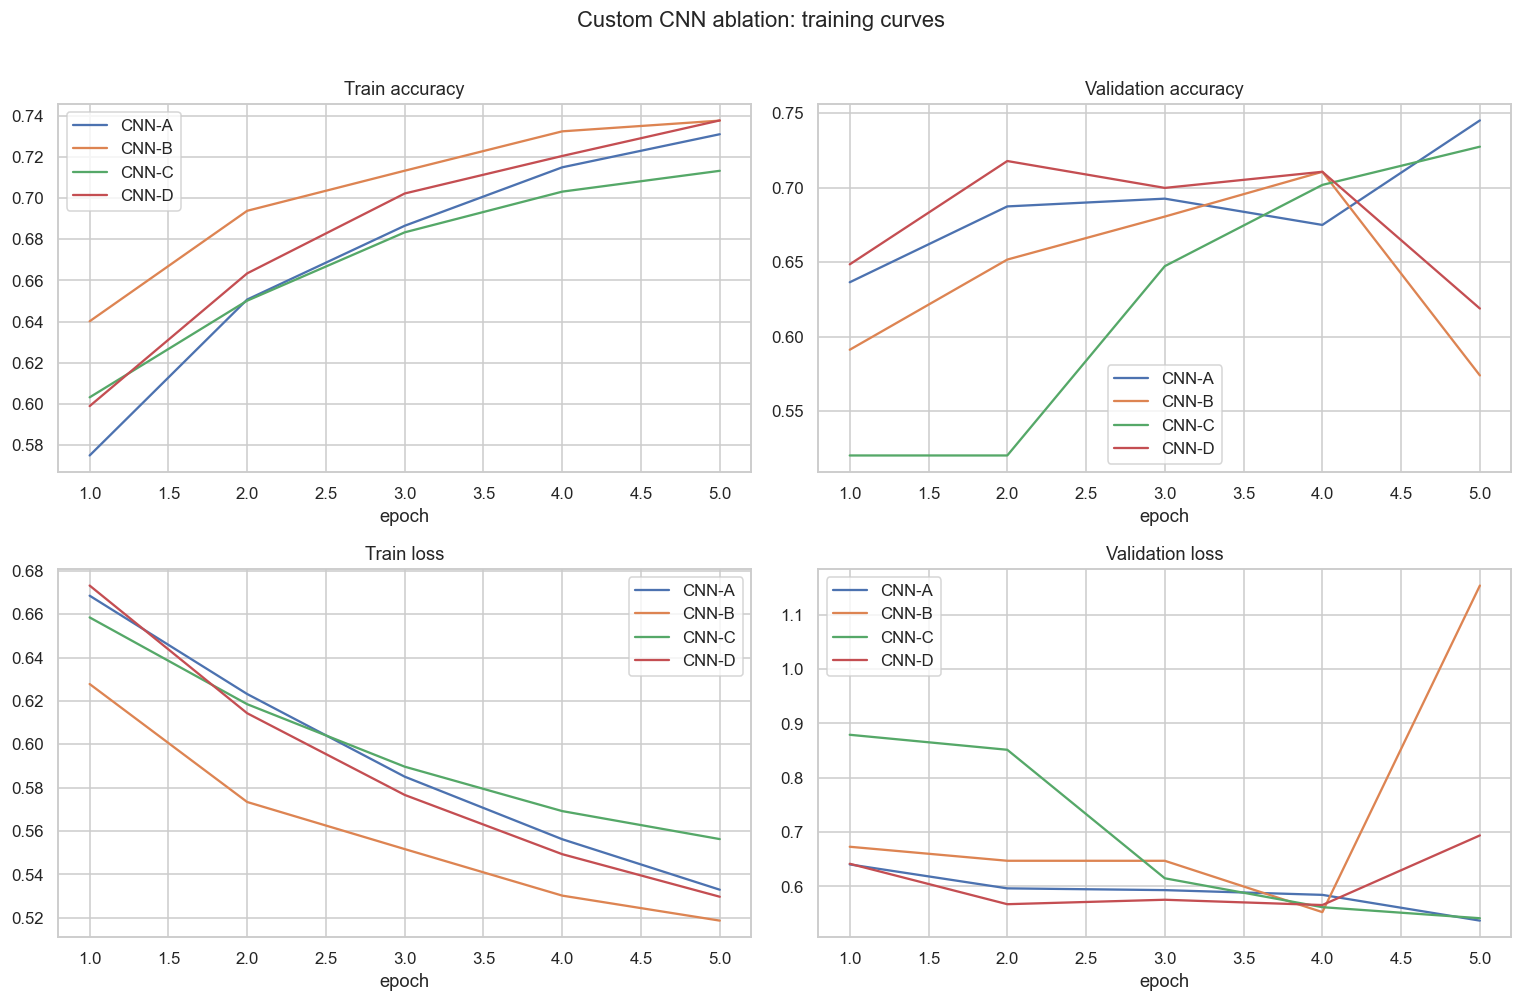

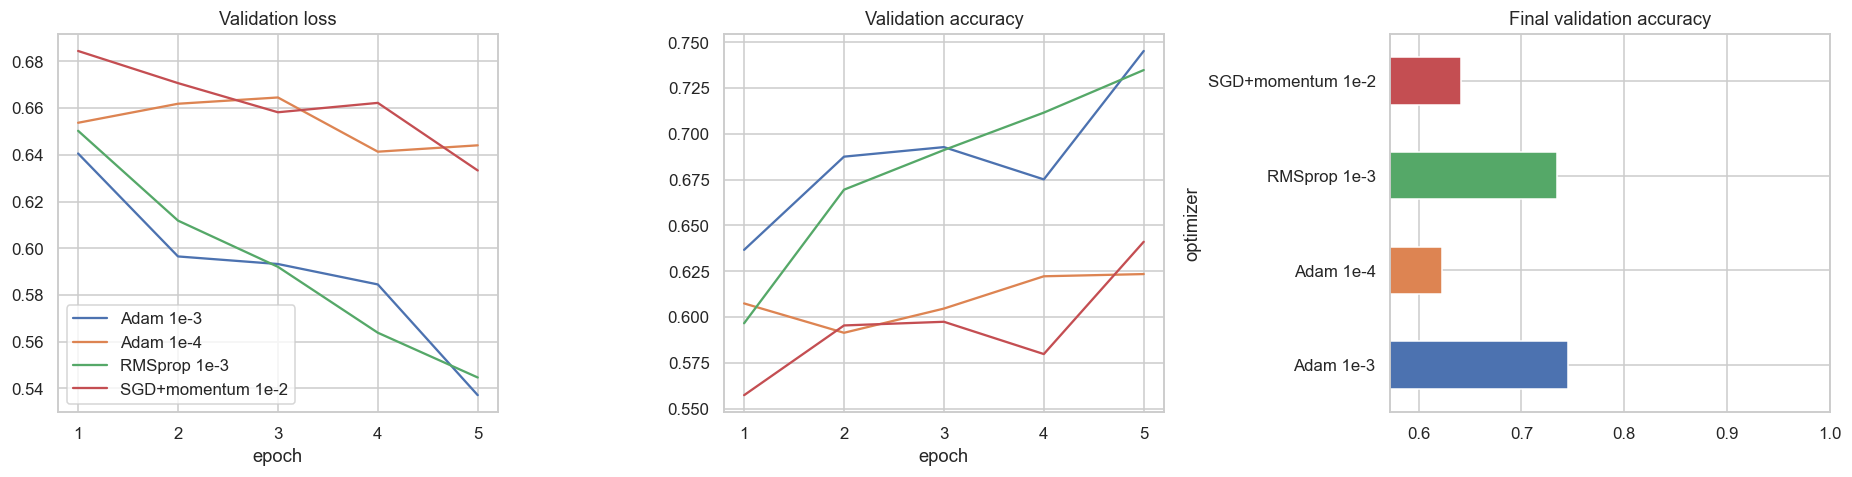

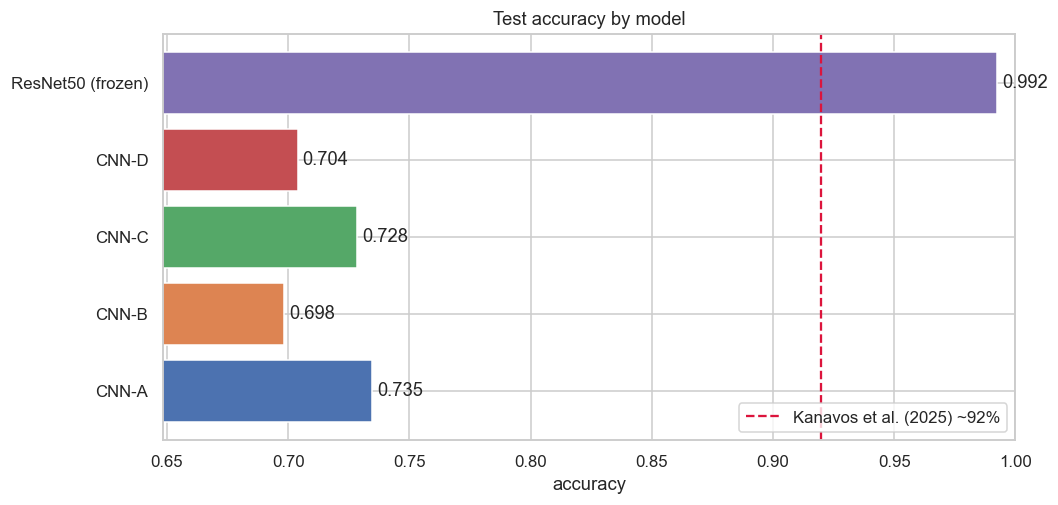

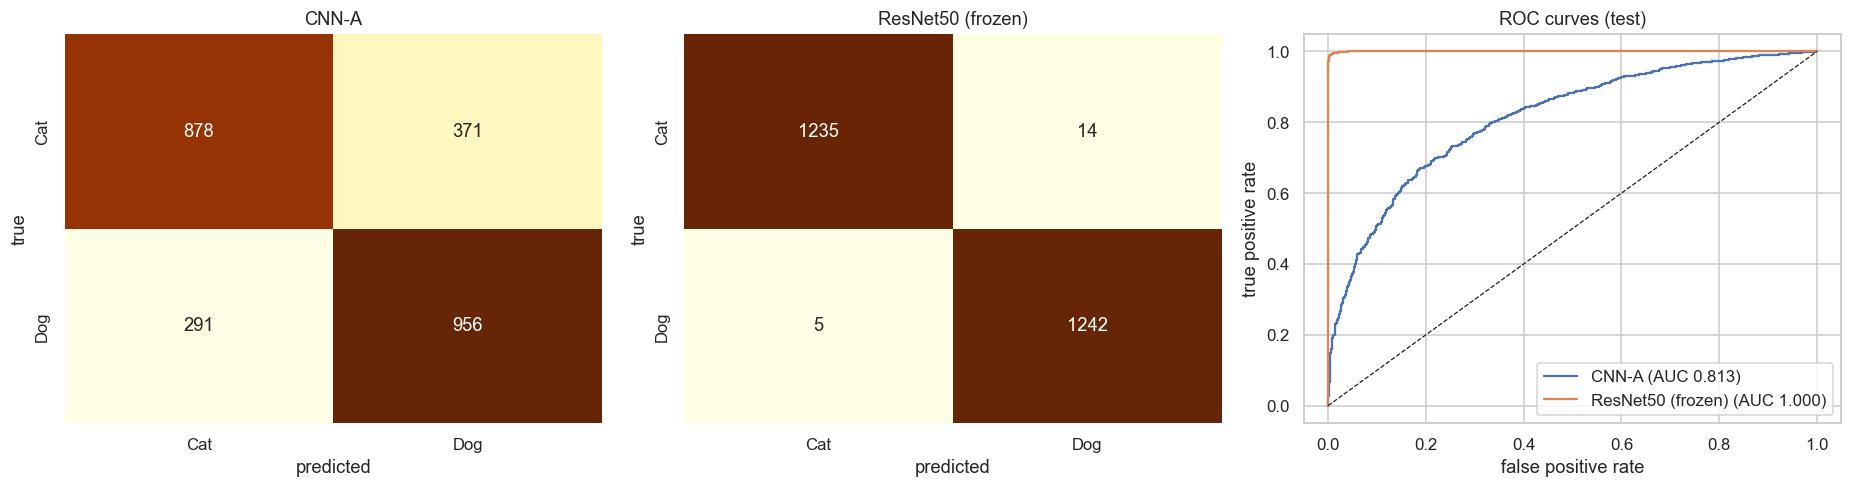

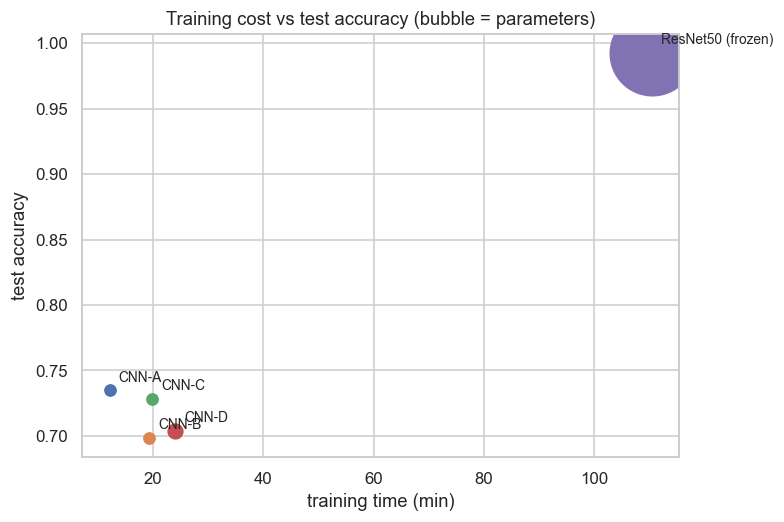

In [35]:
short = lambda n: n.split("  ")[0] if n.startswith("CNN") else n

# 1) CNN ablation training curves
fig, ax = plt.subplots(2, 2, figsize=(14, 9))
for n, h in HIST.items():
    if n.startswith("CNN"):
        ep = np.arange(1, len(h["loss"]) + 1)
        ax[0, 0].plot(ep, h["accuracy"], label=short(n));     ax[0, 1].plot(ep, h["val_accuracy"], label=short(n))
        ax[1, 0].plot(ep, h["loss"], label=short(n));         ax[1, 1].plot(ep, h["val_loss"], label=short(n))
for a, t in zip(ax.ravel(), ["Train accuracy", "Validation accuracy", "Train loss", "Validation loss"]):
    a.set(title=t, xlabel="epoch"); a.legend()
plt.suptitle("Custom CNN ablation: training curves", y=1.01); plt.tight_layout()
plt.savefig("results/figures/cnn_ablation_curves.png"); plt.show()

# 2) optimizer comparison
fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))
for o, h in OPT_HIST.items():
    ep = np.arange(1, len(h["loss"]) + 1); ax[0].plot(ep, h["val_loss"], label=o); ax[1].plot(ep, h["val_accuracy"], label=o)
ax[0].set(title="Validation loss", xlabel="epoch"); ax[1].set(title="Validation accuracy", xlabel="epoch"); ax[0].legend()
opt_table["val_acc"].plot.barh(ax=ax[2], color=sns.color_palette("deep", len(opt_table)))
ax[2].set(title="Final validation accuracy", xlim=(max(0, opt_table.val_acc.min() - 0.05), 1))
plt.tight_layout(); plt.savefig("results/figures/optimizer_comparison.png"); plt.show()

# 3) test accuracy of every model vs the 92% benchmark from Kanavos et al. (2025)
t = table["test_acc"]
fig, ax = plt.subplots(figsize=(10, 4.8))
bars = ax.barh([short(n) for n in t.index], t.values, color=sns.color_palette("deep", len(t)))
ax.axvline(0.92, color="crimson", ls="--", label="Kanavos et al. (2025) ~92%")
for b, v in zip(bars, t.values): ax.text(v + 0.002, b.get_y() + b.get_height() / 2, f"{v:.3f}", va="center")
ax.set(xlim=(max(0.5, t.min() - 0.05), 1.0), title="Test accuracy by model", xlabel="accuracy"); ax.legend(loc="lower right")
plt.savefig("results/figures/test_accuracy_comparison.png"); plt.show()

# 4) confusion matrices and ROC for best CNN vs ResNet50
show = [BEST_CNN, "ResNet50 (frozen)"]
fig, ax = plt.subplots(1, 3, figsize=(17, 4.6))
for a, n in zip(ax[:2], show):
    cm = confusion_matrix(test_data.classes, (PROBS[n] > 0.5).astype(int))
    sns.heatmap(cm, annot=True, fmt="d", cmap="YlOrBr", cbar=False, ax=a, xticklabels=["Cat", "Dog"], yticklabels=["Cat", "Dog"])
    a.set(title=short(n), xlabel="predicted", ylabel="true")
for n in show:
    fpr, tpr, _ = roc_curve(test_data.classes, PROBS[n]); ax[2].plot(fpr, tpr, label=f"{short(n)} (AUC {RESULTS[n]['auc']:.3f})")
ax[2].plot([0, 1], [0, 1], "k--", lw=0.8); ax[2].set(title="ROC curves (test)", xlabel="false positive rate", ylabel="true positive rate"); ax[2].legend(loc="lower right")
plt.tight_layout(); plt.savefig("results/figures/confusion_and_roc.png"); plt.show()

# 5) training cost vs accuracy
fig, ax = plt.subplots(figsize=(7, 5))
for n in table.index:
    ax.scatter(table.loc[n, "train_min"], table.loc[n, "test_acc"], s=table.loc[n, "params"] / 8000 + 40)
    ax.annotate(short(n), (table.loc[n, "train_min"], table.loc[n, "test_acc"]), textcoords="offset points", xytext=(6, 6), fontsize=9)
ax.set(title="Training cost vs test accuracy (bubble = parameters)", xlabel="training time (min)", ylabel="test accuracy")
plt.savefig("results/figures/cost_vs_accuracy.png"); plt.show()

# 12. Robustness test (blur, noise, darkening), as promised in the proposal (after Kaplan et al., 2021)

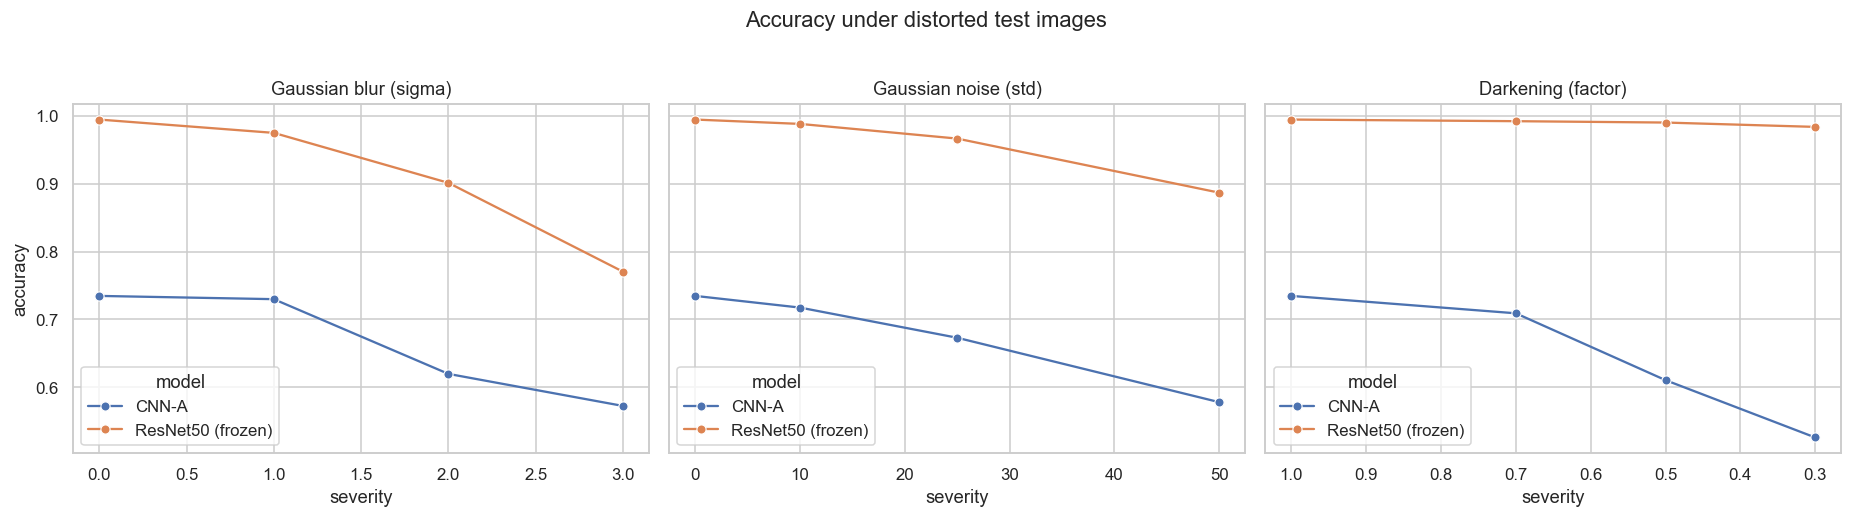

model                         CNN-A  ResNet50 (frozen)
distortion            level                           
Darkening (factor)    0.3    0.5260             0.9840
                      0.5    0.6106             0.9904
                      0.7    0.7091             0.9924
                      1.0    0.7348             0.9948
Gaussian blur (sigma) 0.0    0.7348             0.9948
                      1.0    0.7300             0.9752
                      2.0    0.6198             0.9014
                      3.0    0.5725             0.7704
Gaussian noise (std)  0.0    0.7348             0.9948
                      10.0   0.7175             0.9884
                      25.0   0.6731             0.9667
                      50.0   0.5781             0.8870

In [36]:
def gaussian_blur(x, s):
    if s == 0: return x
    sigma = s * x.shape[1] / 128.0                      # same visual blur at 128 px and 224 px
    r = int(max(1, round(3 * sigma))); ax_ = tf.range(-r, r + 1, dtype=tf.float32)
    k = tf.exp(-(ax_ ** 2) / (2 * sigma ** 2)); k = k / tf.reduce_sum(k)
    k2 = tf.tile(tf.tensordot(k, k, axes=0)[:, :, None, None], [1, 1, 3, 1])
    return tf.clip_by_value(tf.nn.depthwise_conv2d(x, k2, [1, 1, 1, 1], "SAME"), 0.0, 255.0)
def add_noise(x, s):
    return x if s == 0 else tf.clip_by_value(x + tf.random.normal(tf.shape(x), stddev=float(s), seed=SEED), 0.0, 255.0)
def darken(x, s): return x * s

DISTORTIONS = {"Gaussian blur (sigma)": (gaussian_blur, [0, 1, 2, 3]),
               "Gaussian noise (std)":  (add_noise,     [0, 10, 25, 50]),
               "Darkening (factor)":    (darken,        [1.0, 0.7, 0.5, 0.3])}

res_test_raw, _ = to_ds(test_df, 224, False)           # raw 0-255 pixels; ResNet preprocessing is applied AFTER the distortion
rob_rows = []
for dname, (fn, levels) in DISTORTIONS.items():
    for lvl in levels:
        d_cnn = cnn_test.map(lambda x, y, fn=fn, lvl=lvl: (fn(x, lvl), y), num_parallel_calls=AUTOTUNE)
        d_res = res_test_raw.map(lambda x, y, fn=fn, lvl=lvl: (preprocess_input(fn(x, lvl)), y), num_parallel_calls=AUTOTUNE)
        for mname, model, ds in [(short(BEST_CNN), CNN_MODELS[BEST_CNN], d_cnn), ("ResNet50 (frozen)", Model, d_res)]:
            acc = accuracy_score(y_test, (model.predict(ds, verbose=0).ravel() > 0.5).astype(int))
            rob_rows.append(dict(distortion=dname, level=lvl, model=mname, accuracy=acc))
rob = pd.DataFrame(rob_rows); rob.to_csv("results/metrics/robustness-results.csv", index=False)

fig, ax = plt.subplots(1, 3, figsize=(17, 4.6), sharey=True)
for a, (dname, g) in zip(ax, rob.groupby("distortion", sort=False)):
    sns.lineplot(data=g, x="level", y="accuracy", hue="model", marker="o", ax=a); a.set(title=dname, xlabel="severity")
    if dname.startswith("Dark"): a.invert_xaxis()
plt.suptitle("Accuracy under distorted test images", y=1.02); plt.tight_layout()
plt.savefig("results/figures/robustness.png"); plt.show()
rob.pivot_table(index=["distortion", "level"], columns="model", values="accuracy").round(4)

# 13. Save the numbers for the report

In [37]:
json.dump({k: {m: [float(x) for x in v] for m, v in h.items()} for k, h in HIST.items()}, open("results/training/training-histories.json", "w"))
print("Saved tables and figures in:", os.path.abspath("results"))
print(sorted(os.listdir("results/figures")))

Saved tables and figures in: /Users/sabyasachi/Documents/programming_forai_project_Proposal/results
['cnn_ablation_curves.png', 'confusion_and_roc.png', 'cost_vs_accuracy.png', 'optimizer_comparison.png', 'robustness.png', 'test_accuracy_comparison.png']


In [38]:
print("Corrupt files removed:", len(bad_files))
for n, h in HIST.items():
    print(f"{n}: epochs run = {len(h['loss'])}, best val_acc = {max(h['val_accuracy']):.4f}, min val_loss = {min(h['val_loss']):.4f}")

Corrupt files removed: 1
CNN-A  3 blocks, no BN, no dropout: epochs run = 5, best val_acc = 0.7452, min val_loss = 0.5371
CNN-B  3 blocks, BN: epochs run = 5, best val_acc = 0.7107, min val_loss = 0.5527
CNN-C  3 blocks, BN, dropout 0.3: epochs run = 5, best val_acc = 0.7276, min val_loss = 0.5415
CNN-D  4 blocks, BN, dropout 0.5: epochs run = 5, best val_acc = 0.7179, min val_loss = 0.5658
ResNet50 (frozen): epochs run = 5, best val_acc = 0.9920, min val_loss = 0.0243
